In [1]:
import pandas as pd
import json
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from utils import normalize_text

In [2]:
DATASET_PATH = "data/openalex_ai_healthcare_publications_1980_2026_filtered.csv"
METHOD_TERMS_PATH = "config/ai_method_vocabulary.json"

In [3]:
publications_df = pd.read_csv(DATASET_PATH)

In [15]:
METHOD_TERMS_FILE = "config/ai_method_vocabulary.json"

with open(METHOD_TERMS_FILE, "r", encoding="utf-8") as f:
    method_config = json.load(f)

METHOD_TERMS = method_config["method_terms"]

In [16]:
PERIODS = {
    "1980-2011": (1980, 2011),
    "2012-2016": (2012, 2016),
    "2017-2021": (2017, 2021),
    "2022-2026": (2022, 2026),
}

In [17]:
TEXT_COLUMNS = ["title", "keywords"]

### **2. Paradigm and Method Shift Over Time**
This section analyzes how AI methods changed across historical periods. Publication titles and keywords are combined into a single text field, normalized, and matched against a predefined vocabulary of AI method terms. The resulting term frequencies are used to generate word clouds for each period.

In [18]:
publications_df["combined_text"] = (
    publications_df[TEXT_COLUMNS]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

In [19]:
def count_method_terms(text_series, method_terms):
    full_text = " ".join(text_series.fillna("").astype(str).apply(normalize_text))

    method_counts = Counter()

    for display_name, variants in method_terms.items():
        count = 0

        for variant in variants:
            variant = variant.lower().strip()
            pattern = r"\b" + re.escape(variant) + r"\b"
            count += len(re.findall(pattern, full_text))

        if count > 0:
            method_counts[display_name] = count

    return method_counts

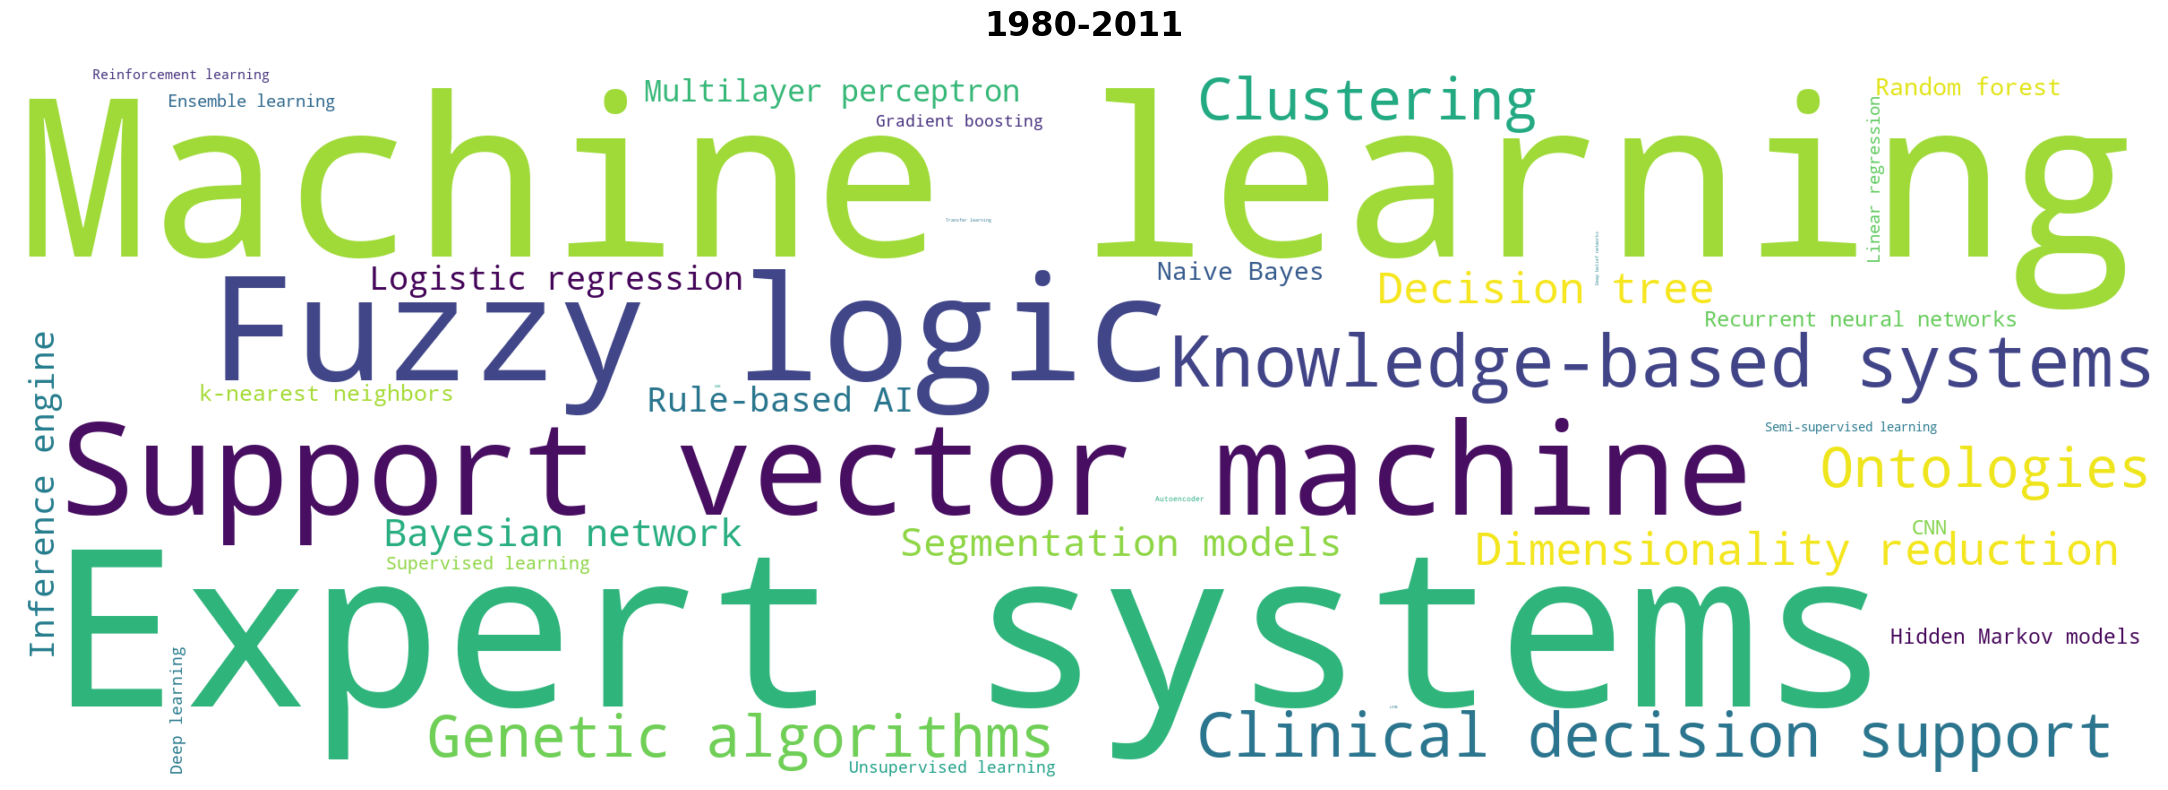

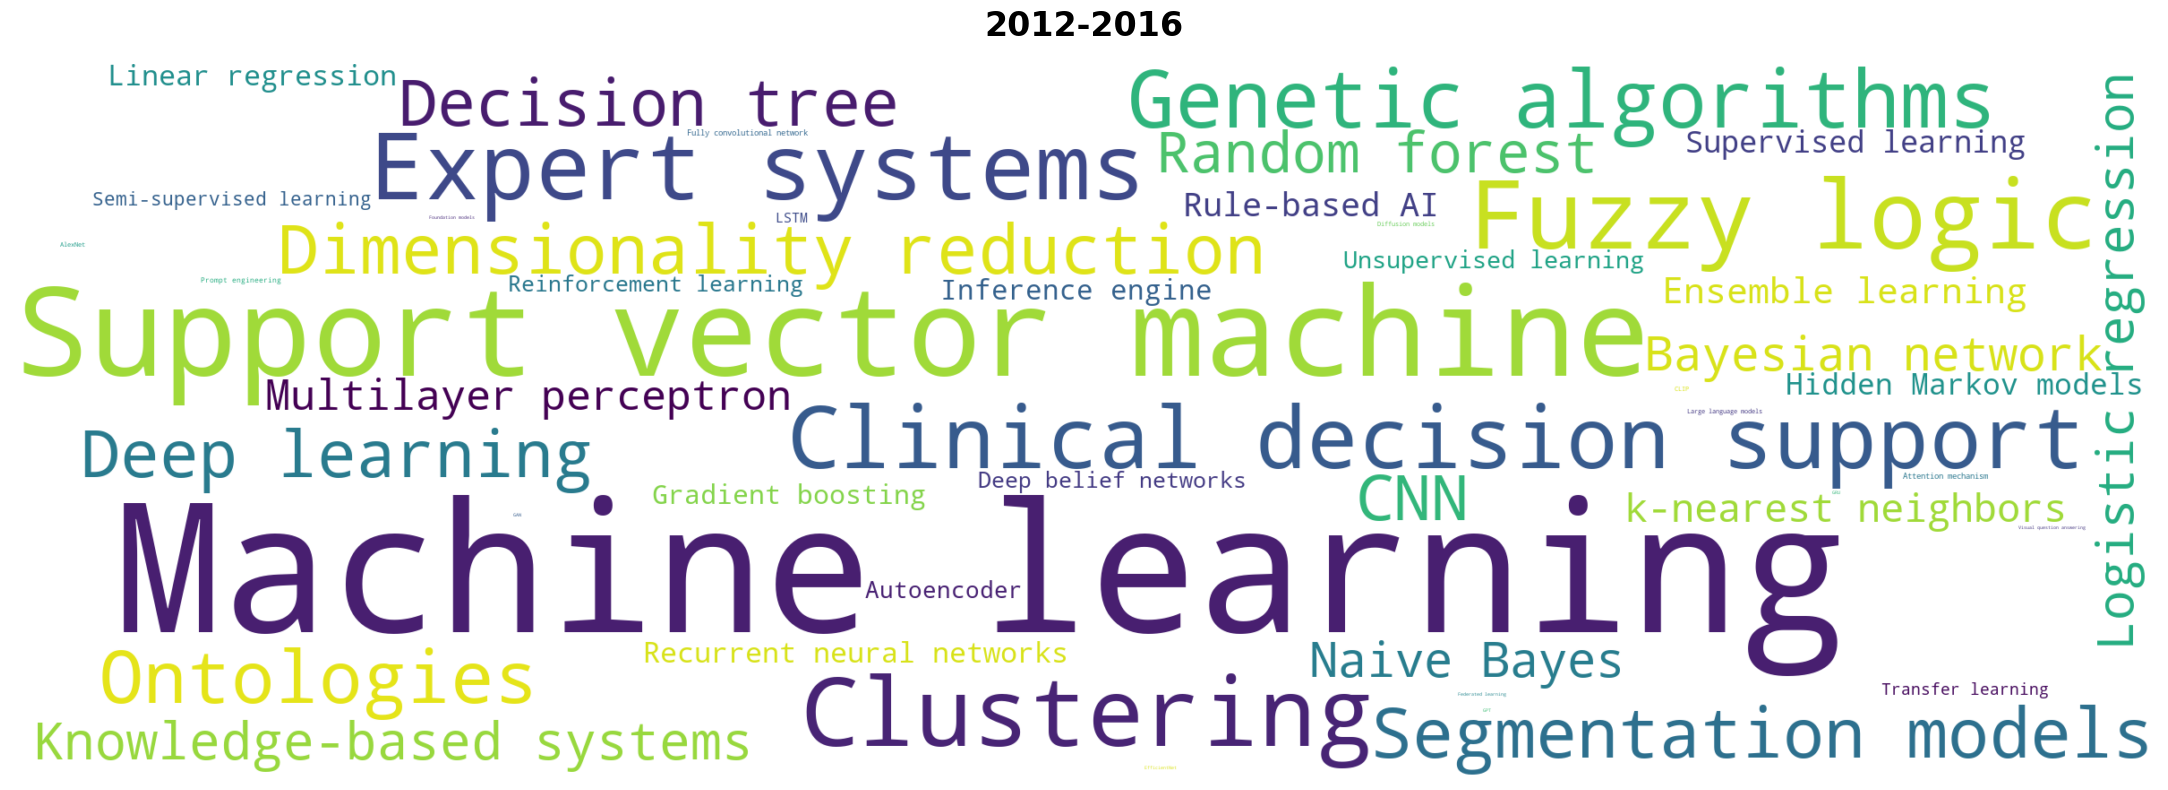

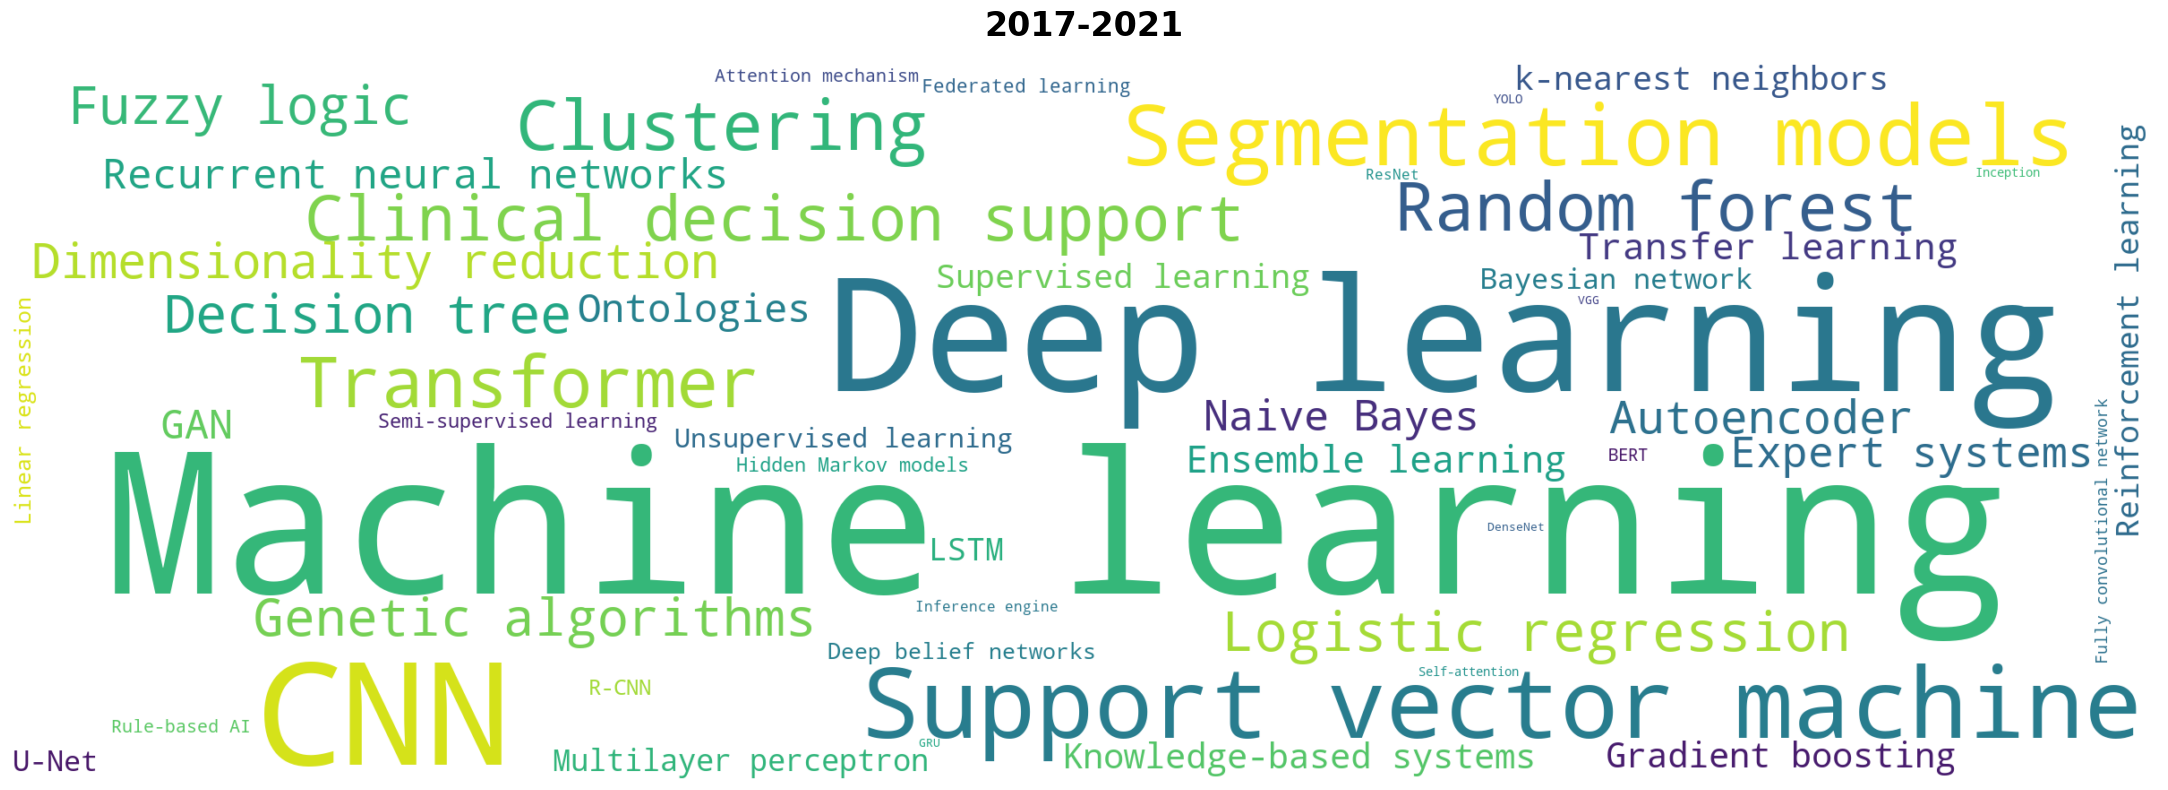

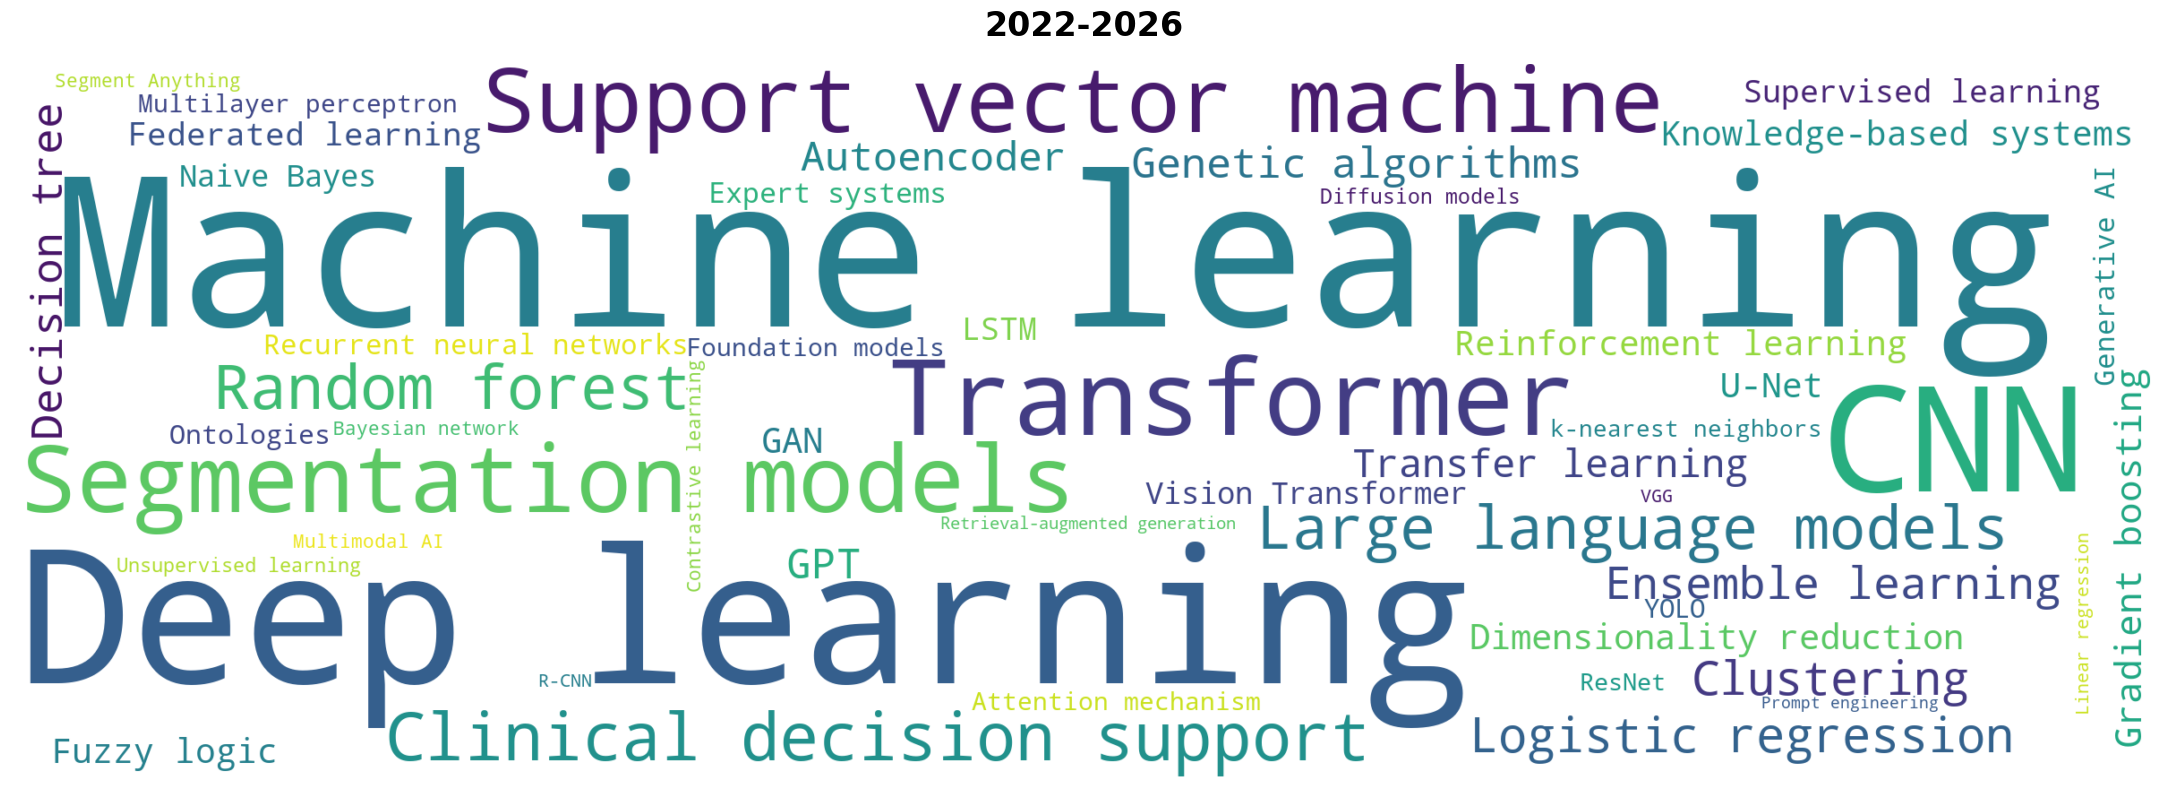

In [21]:
for period_name, (start_year, end_year) in PERIODS.items():
    period_df = publications_df[
        (publications_df["publication_year"] >= start_year) &
        (publications_df["publication_year"] <= end_year)
    ].copy()

    method_counts = count_method_terms(period_df["combined_text"], METHOD_TERMS)
    
    wc = WordCloud(
        background_color="white",
        width=2400,
        height=800,
        max_words=50,
        collocations=False
    )

    wc.generate_from_frequencies(method_counts)

    plt.figure(figsize=(24, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{period_name}", fontsize=24, weight="bold", pad=20)
    plt.tight_layout()

    filename = f"figures/method_wordcloud_{period_name.replace('-', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()